In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [5]:
df.shape

(918, 12)

In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='HeartDisease'>

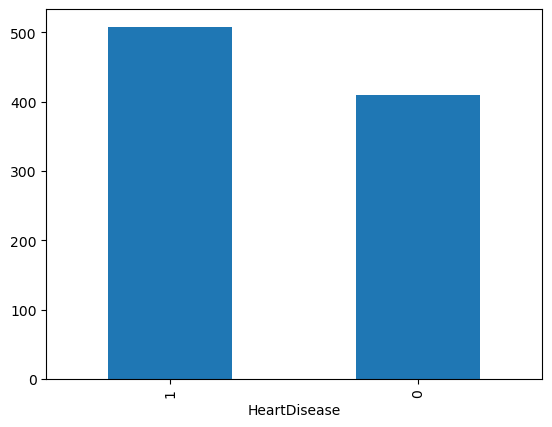

In [10]:
df['HeartDisease'].value_counts().plot(kind='bar')

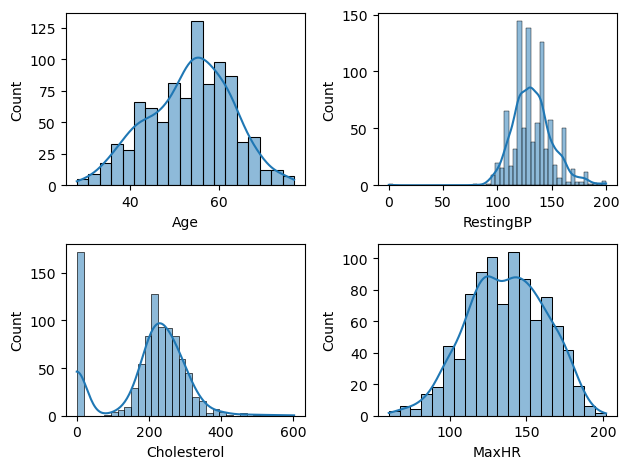

In [11]:
def plotting(var,num):   # (var) is just a parameter name (a variable inside the function).
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

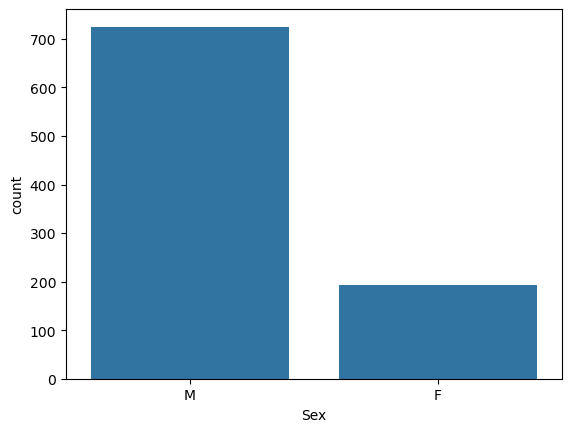

In [12]:
sns.countplot(x = df['Sex'])

<Axes: xlabel='Sex', ylabel='count'>

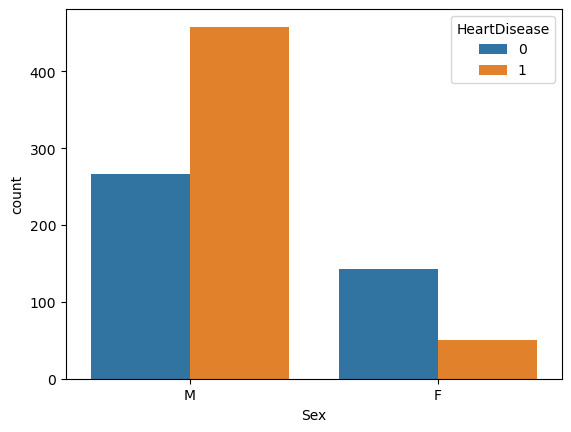

In [13]:
sns.countplot(x = df['Sex'], hue=df['HeartDisease'])   # 0 = NO Disease , 1 = Disease

In [14]:
df.select_dtypes(include= "number").columns   # Show only numerical columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

In [15]:
df.select_dtypes(include= "object").columns  # Show only categorical values

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [16]:
# Seeing which columns (features) are most useful to predict HeartDiseas

corr = df.corr(numeric_only=True)

print(corr['HeartDisease'].sort_values(ascending=False))

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64


In [17]:
corr['HeartDisease'].abs().sort_values(ascending=False) # abs()= convert all negative to positive 

HeartDisease    1.000000
Oldpeak         0.403951
MaxHR           0.400421
Age             0.282039
FastingBS       0.267291
Cholesterol     0.232741
RestingBP       0.107589
Name: HeartDisease, dtype: float64

In [18]:
# Doing oneHOt Encoding

df_encode = pd.get_dummies(df,drop_first=True)

In [19]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144,193,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130,236,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [20]:
df_encode = df_encode.astype(int)   # converting above data (True,Fales) to "integer"

In [21]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [22]:
x = df_encode.drop('HeartDisease', axis = 1)   # We are seprating the "X" and "Y" features
y = df_encode['HeartDisease']

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.20,
                                                    random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipelines ={
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression())
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    
    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier())  # no scaler needed
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ])
}

In [26]:
# Seeing side by side result 

result =[]

for name, pipe in pipelines.items():
    pipe.fit(x_train,y_train)
    y_pred = pipe.predict(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    result.append({
        'model': name,
        'Accuracy': round(acc, 4),
        'f1 score': round(f1, 4)
    })
        



result


[{'model': 'Logistic Regression', 'Accuracy': 0.8533, 'f1 score': 0.8696},
 {'model': 'KNN', 'Accuracy': 0.8478, 'f1 score': 0.8641},
 {'model': 'Naive Bayes', 'Accuracy': 0.8641, 'f1 score': 0.8792},
 {'model': 'Decision Tree', 'Accuracy': 0.8152, 'f1 score': 0.8396},
 {'model': 'SVM', 'Accuracy': 0.8804, 'f1 score': 0.8962}]

In [27]:
for name, pipe in pipelines.items():
    pipe.fit(x_train, y_train)
    acc = pipe.score(x_test, y_test)
    print(f"{name}: {acc}")

Logistic Regression: 0.8532608695652174
KNN: 0.8478260869565217
Naive Bayes: 0.8641304347826086
Decision Tree: 0.7934782608695652
SVM: 0.8804347826086957


In [28]:
best_model = max(result, key=lambda x: x['f1 score'])

print("Best Model based on F1 Score:")
print(best_model)

Best Model based on F1 Score:
{'model': 'SVM', 'Accuracy': 0.8804, 'f1 score': 0.8962}


In [29]:
best_model_acc = max(result, key=lambda x: x['Accuracy'])

print("Best Model based on Accuracy:")
print(best_model_acc)

Best Model based on Accuracy:
{'model': 'SVM', 'Accuracy': 0.8804, 'f1 score': 0.8962}


In [30]:
worst_model_acc = min(result, key=lambda x: x['Accuracy'])

print("Worst Model based on Accuracy:")
print(worst_model_acc)

Worst Model based on Accuracy:
{'model': 'Decision Tree', 'Accuracy': 0.8152, 'f1 score': 0.8396}


In [31]:
from sklearn.metrics import confusion_matrix

y_pred = pipe.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[67 10]
 [12 95]]


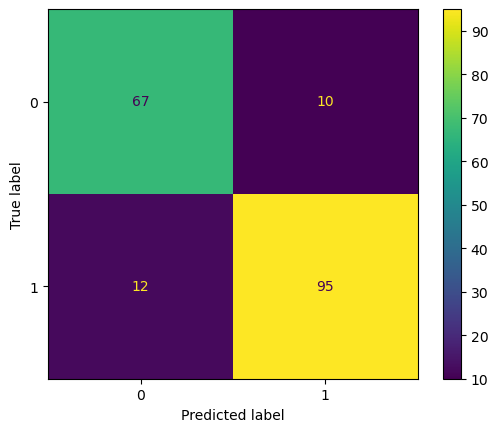

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(pipe, x_test, y_test)